# Counterfactual Regret Minimization (CFR) et Poker IA

**Groupe E5 — Nicolas Naegelen & Arthur Gallier**  
EPITA 2026 — Intelligence Symbolique

---

## Plan

1. **Contexte théorique** — jeux à information imparfaite, regret, Nash
2. **Kuhn Poker** — description formelle et arbre de jeu
3. **CFR Vanilla** — implémentation et convergence vers Nash
4. **Oracle Best-Response** — mesure de l'exploitabilité
5. **CFR+** — comparaison de convergence
6. **Scalabilité** — Leduc Hold'em et défis computationnels
7. **Conclusion et perspectives** — Libratus, Pluribus, MCCFR

In [1]:
import sys
sys.path.insert(0, '.')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import defaultdict

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['font.size'] = 12

print('Imports OK')

Imports OK


---

## 1. Contexte théorique

### 1.1 Jeux à information imparfaite

Le poker est un **jeu à information imparfaite** : chaque joueur connaît sa propre main mais pas celle de l'adversaire. Contrairement au jeu d'échecs (information parfaite), où minimax + alpha-beta suffisent, il faut raisonner sur des **ensembles d'information** (information sets) — l'ensemble des états du monde compatibles avec ce qu'un joueur a observé.

### 1.2 Regret et Regret Matching

Le **regret** d'une action $a$ à l'itération $T$ est :

$$R^T(I, a) = \sum_{t=1}^{T} \pi^t_{-i}(I) \cdot \left[ v_i(\sigma^t_{I \to a}, \sigma^t_{-i}) - v_i(\sigma^t) \right]$$

où $\pi^t_{-i}(I)$ est la probabilité **contrefactuelle** d'atteindre $I$ (reach de l'adversaire).

La **stratégie par regret matching** convertit les regrets cumulés en probabilités :

$$\sigma^{t+1}(I, a) = \frac{\max(R^t(I, a), 0)}{\sum_{a'} \max(R^t(I, a'), 0)}$$

### 1.3 Théorème de convergence CFR

**Théorème (Zinkevich et al. 2007)** : Dans un jeu à somme nulle à deux joueurs, la stratégie moyenne $\bar{\sigma}^T$ converge vers un équilibre de Nash à taux $O(1/\sqrt{T})$ :

$$\text{Exploitabilité}(\bar{\sigma}^T) \leq \frac{\Delta \sqrt{|\mathcal{I}| \cdot |A|}}{\sqrt{T}}$$

C'est le fondement théorique de **Libratus** (2017, poker tête-à-tête) et **Pluribus** (2019, 6 joueurs).

---

## 2. Kuhn Poker — Arbre de Jeu

**Kuhn Poker** (Kuhn, 1950) est le jeu de poker minimal permettant d'étudier le bluff stratégique :

- **3 cartes** : J (Valet), Q (Dame), K (Roi)
- **2 joueurs** : chacun mise 1 jeton (ante)
- **Actions** : `p` (passe/check) ou `b` (mise)
  - Si l'adversaire mise, on peut `p` (fold) ou `b` (call)
- **Gain Nash théorique** : `-1/18 ≈ -0.0556` pour le joueur 0 (désavantage de parler en premier)

### 12 ensembles d'information

| Joueur | Ensemble | Signification |
|--------|----------|---------------|
| P0 | J:, Q:, K: | Premier choix (check ou bet) |
| P1 | J:p, Q:p, K:p | Face au check de P0 |
| P1 | J:b, Q:b, K:b | Face à la mise de P0 |
| P0 | J:pb, Q:pb, K:pb | P0 a check, P1 a bet |

### Équilibre de Nash analytique (paramètre $\alpha = 1/3$)

| Info set | Stratégie Nash |
|----------|----------------|
| J: | check=2/3, bet=1/3 (bluff) |
| Q: | check=1 |
| K: | bet=1 |
| J:pb | fold=1 |
| Q:pb | fold=1/3, **call=2/3** |
| K:pb | call=1 |
| J:p | check=2/3, **bet=1/3** (bluff) |
| Q:p | check=1 |
| K:p | bet=1 |
| J:b | fold=1 |
| Q:b | fold=2/3, call=1/3 |
| K:b | call=1 |

In [2]:
from src.kuhn_poker import CARDS, CARD_NAMES, is_terminal, current_player, terminal_utility, get_actions, info_set_key

def build_game_tree(cards, history='', depth=0):
    """Affiche l'arbre de jeu pour un deal donné."""
    prefix = '  ' * depth
    player = current_player(history)
    
    if is_terminal(history):
        u = terminal_utility(history, cards)
        print(f"{prefix}[TERMINAL] hist={history!r} u={u:+.0f}")
        return
    
    card_str = CARD_NAMES[cards[player]]
    print(f"{prefix}P{player}({card_str}) @ hist={history!r}")
    for action in get_actions(history):
        label = 'check/fold' if action=='p' else 'bet/call'
        print(f"{prefix}  → {label}")
        build_game_tree(cards, history + action, depth + 2)

print("=== Arbre pour deal (J, K) [P0=J, P1=K] ===")
build_game_tree((0, 2))

=== Arbre pour deal (J, K) [P0=J, P1=K] ===
P0(J) @ hist=''
  → check/fold
    P1(K) @ hist='p'
      → check/fold
        [TERMINAL] hist='pp' u=-1
      → bet/call
        P0(J) @ hist='pb'
          → check/fold
            [TERMINAL] hist='pbp' u=-1
          → bet/call
            [TERMINAL] hist='pbb' u=-2
  → bet/call
    P1(K) @ hist='b'
      → check/fold
        [TERMINAL] hist='bp' u=+1
      → bet/call
        [TERMINAL] hist='bb' u=-2


---

## 3. CFR Vanilla — Implémentation et Convergence

In [3]:
from src.cfr import CFR
from src.best_response import exploitability, best_response_value

# Entraînement CFR vanilla avec mesure d'exploitabilité tous les 50 itérations
N_ITER = 5000
EVAL_EVERY = 50

cfr_vanilla = CFR()
expl_vanilla = []
checkpoints = list(range(EVAL_EVERY, N_ITER + 1, EVAL_EVERY))

for t in checkpoints:
    cfr_vanilla.train(EVAL_EVERY)
    profile = cfr_vanilla.get_strategy_profile()
    expl_vanilla.append(exploitability(profile))

print(f"Exploitabilité finale après {N_ITER} itérations : {expl_vanilla[-1]:.5f}")
print(f"Nash théorique : 0.00000")

Exploitabilité finale après 5000 itérations : 0.00466
Nash théorique : 0.00000


In [4]:
# Affichage de la stratégie CFR après convergence
cfr_final = CFR()
cfr_final.train(100000)
profile_final = cfr_final.get_strategy_profile()

nash_reference = {
    'J:':   [2/3, 1/3],
    'Q:':   [1.0, 0.0],
    'K:':   [0.0, 1.0],
    'J:pb': [1.0, 0.0],
    'Q:pb': [1/3, 2/3],
    'K:pb': [0.0, 1.0],
    'J:p':  [2/3, 1/3],
    'Q:p':  [1.0, 0.0],
    'K:p':  [0.0, 1.0],
    'J:b':  [1.0, 0.0],
    'Q:b':  [2/3, 1/3],
    'K:b':  [0.0, 1.0],
}

print(f"{'Info Set':10s} {'check/fold':>12s} {'bet/call':>10s} | {'Nash check':>12s} {'Nash bet':>10s}")
print('-' * 60)
for key in sorted(profile_final.keys()):
    v = profile_final[key]
    n = nash_reference.get(key, [0.5, 0.5])
    print(f"{key:10s} {v[0]:>12.3f} {v[1]:>10.3f} | {n[0]:>12.3f} {n[1]:>10.3f}")

Info Set     check/fold   bet/call |   Nash check   Nash bet
------------------------------------------------------------
J:                0.780      0.220 |        0.667      0.333
J:b               1.000      0.000 |        1.000      0.000
J:p               0.668      0.332 |        0.667      0.333
J:pb              1.000      0.000 |        1.000      0.000
K:                0.337      0.663 |        0.000      1.000
K:b               0.000      1.000 |        0.000      1.000
K:p               0.000      1.000 |        0.000      1.000
K:pb              0.000      1.000 |        0.000      1.000
Q:                1.000      0.000 |        1.000      0.000
Q:b               0.664      0.336 |        0.667      0.333
Q:p               1.000      0.000 |        1.000      0.000
Q:pb              0.445      0.555 |        0.333      0.667


---

## 4. Oracle Best-Response — Mesure d'Exploitabilité

L'**exploitabilité** mesure à quel point une stratégie s'écarte de l'équilibre de Nash :

$$\text{Expl}(\sigma) = \underbrace{\max_{\sigma_0'} u_0(\sigma_0', \sigma_1)}_{\text{BR de P0}} + \underbrace{\max_{\sigma_1'} u_1(\sigma_0, \sigma_1')}_{\text{BR de P1}}$$

À l'équilibre de Nash : $\text{Expl}(\sigma^*) = 0$.

**Implémentation correcte** : le BR doit être une fonction des **ensembles d'information**, pas des deals individuels. On calcule les valeurs d'action pondérées par la reach probability de l'adversaire, puis on choisit l'action maximale par info set.

In [5]:
import numpy as np

# Vérification : exploitabilité du Nash analytique = 0
nash_np = {k: np.array(v) for k, v in nash_reference.items()}
expl_nash = exploitability(nash_np)
print(f"Exploitabilité du Nash analytique : {expl_nash:.6f}  (théorique : 0.0)")

# Valeur du jeu sous le Nash
from src.kuhn_poker import is_terminal, current_player, terminal_utility, info_set_key, get_actions, CARDS
card_perms = [(c0,c1) for c0 in CARDS for c1 in CARDS if c0!=c1]

def game_value(cards, h, profile):
    if is_terminal(h): return terminal_utility(h, cards)
    p = current_player(h); acts = get_actions(h); n = len(acts)
    s = profile[info_set_key(p, cards[p], h)]
    return sum(s[i]*game_value(cards, h+a, profile) for i,a in enumerate(acts))

gv = sum(game_value(c, '', nash_np) for c in card_perms) / len(card_perms)
print(f"Valeur du jeu (Nash) : {gv:.4f}  (théorique : {-1/18:.4f})")

Exploitabilité du Nash analytique : -0.000000  (théorique : 0.0)
Valeur du jeu (Nash) : -0.0556  (théorique : -0.0556)


---

## 5. CFR+ — Comparaison de Convergence

**CFR+** (Tammelin 2014, amélioré par Brown & Sandholm 2015) introduit deux modifications :

1. **Regrets plancher à 0** : $R^+(I,a) = \max(R^{t-1}(I,a) + r^t(I,a), 0)$  
   → élimine l'effet mémoire des mauvaises décisions passées

2. **Mises à jour alternées** : à l'itération $t$, seul le joueur $t \bmod 2$ met à jour ses regrets  
   → réduit la variance

3. **Pondération linéaire** de la stratégie moyenne : $\bar{\sigma}^t += t \cdot \sigma^t$  
   → pondère davantage les stratégies récentes (plus précises)

In [6]:
from src.cfr import CFRPlus

N_ITER = 5000
EVAL_EVERY = 50

cfr_plus = CFRPlus()
expl_plus = []

for t in range(0, N_ITER, EVAL_EVERY):
    cfr_plus.train(EVAL_EVERY)
    profile = cfr_plus.get_strategy_profile()
    expl_plus.append(exploitability(profile))

print(f"CFR  final exploitabilité : {expl_vanilla[-1]:.5f}")
print(f"CFR+ final exploitabilité : {expl_plus[-1]:.5f}")

CFR  final exploitabilité : 0.00466
CFR+ final exploitabilité : 0.00616


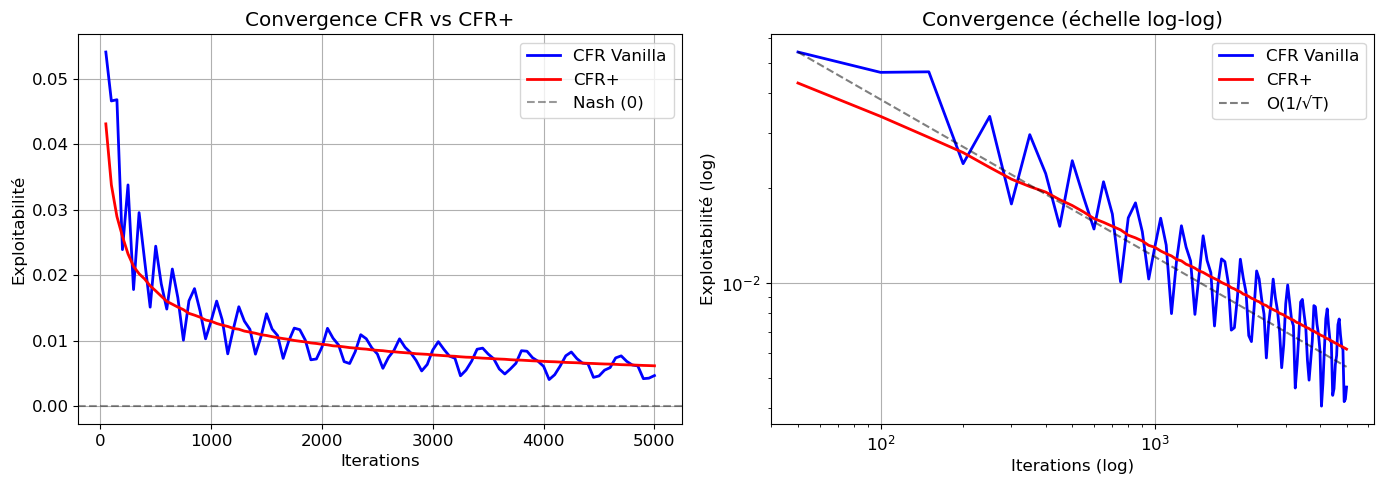

Figure sauvegardée : convergence_cfr.png


In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

iters = checkpoints

# Courbes de convergence
ax1.plot(iters, expl_vanilla, 'b-', label='CFR Vanilla', linewidth=2)
ax1.plot(iters, expl_plus, 'r-', label='CFR+', linewidth=2)
ax1.axhline(0, color='k', linestyle='--', alpha=0.4, label='Nash (0)')
ax1.set_xlabel('Iterations')
ax1.set_ylabel('Exploitabilité')
ax1.set_title('Convergence CFR vs CFR+')
ax1.legend()

# Échelle log-log pour voir la pente
ax2.loglog(iters, expl_vanilla, 'b-', label='CFR Vanilla', linewidth=2)
ax2.loglog(iters, expl_plus, 'r-', label='CFR+', linewidth=2)
# Droite de référence O(1/sqrt(T))
ref_t = np.array(iters)
ax2.loglog(ref_t, expl_vanilla[0] * np.sqrt(iters[0]/ref_t), 'k--', alpha=0.5, label='O(1/√T)')
ax2.set_xlabel('Iterations (log)')
ax2.set_ylabel('Exploitabilité (log)')
ax2.set_title('Convergence (échelle log-log)')
ax2.legend()

plt.tight_layout()
plt.savefig('convergence_cfr.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardée : convergence_cfr.png')

---

## 6. Scalabilité — Leduc Hold'em

Leduc Hold'em est plus complexe que Kuhn poker :

| Propriété | Kuhn Poker | Leduc Hold'em |
|-----------|------------|---------------|
| Cartes | 3 (J,Q,K ×1) | 6 (J,Q,K ×2) |
| Rounds | 1 | 2 (+ carte communautaire) |
| Info sets | 12 | ~288 |
| Noeuds terminaux | 30 | ~10,000+ |
| Mise max round 1 | 2 jetons | 2 jetons |
| Mise max round 2 | — | 4 jetons |

La **main forte** en Leduc : une paire (carte privée = carte communautaire) bat n'importe quelle carte haute.

In [8]:
import time
from src.leduc_poker import LeducCFR

print("=== Profiling Leduc Hold'em CFR ===")

results = []
for n_iter in [10, 50, 100]:
    leduc = LeducCFR()
    t0 = time.time()
    vals, n_deals = leduc.train(n_iter)
    elapsed = time.time() - t0
    
    results.append({
        'iterations': n_iter,
        'time_s': elapsed,
        'nodes_visited': leduc.nodes_visited,
        'info_sets': len(leduc.info_sets),
        'n_deals': n_deals,
    })
    print(f"  T={n_iter:3d}: {elapsed:.2f}s, nodes={leduc.nodes_visited:,}, info_sets={len(leduc.info_sets)}")

print(f"\nKuhn poker info sets: 12")
print(f"Leduc info sets: {results[-1]['info_sets']}")
print(f"Facteur de complexité: ×{results[-1]['info_sets']//12}")

=== Profiling Leduc Hold'em CFR ===
  T= 10: 0.02s, nodes=7,920, info_sets=120
  T= 50: 0.11s, nodes=39,600, info_sets=120


  T=100: 0.21s, nodes=79,200, info_sets=120

Kuhn poker info sets: 12
Leduc info sets: 120
Facteur de complexité: ×10


In [9]:
# Comparaison temps de calcul par itération
import time

kuhn_times = []
kuhn_cfr = CFR()
for _ in range(20):
    t0 = time.time()
    kuhn_cfr.train(100)
    kuhn_times.append((time.time()-t0)/100)

leduc_times = []
leduc_cfr = LeducCFR()
for _ in range(5):
    t0 = time.time()
    leduc_cfr.train(10)
    leduc_times.append((time.time()-t0)/10)

print(f"Kuhn poker : {np.mean(kuhn_times)*1000:.3f} ms/iteration")
print(f"Leduc Hold'em : {np.mean(leduc_times)*1000:.1f} ms/iteration")
print(f"Ratio : ×{np.mean(leduc_times)/np.mean(kuhn_times):.0f}")

Kuhn poker : 0.086 ms/iteration
Leduc Hold'em : 2.0 ms/iteration
Ratio : ×24


### 6.1 Défis de scalabilité et techniques d'abstraction

Pour le Texas Hold'em à mise variable (NLHE) :
- **Nombre d'info sets** : $10^{12}$ à $10^{18}$ selon la variante
- **CFR direct impossible** : nécessite des abstractions

**Techniques utilisées dans Libratus et Pluribus** :

| Technique | Description |
|-----------|-------------|
| **Card abstraction** | Regrouper les mains similaires en buckets |
| **Bet abstraction** | Limiter les tailles de mises possibles |
| **Monte Carlo CFR (MCCFR)** | Échantillonner l'arbre plutôt que l'énumérer |
| **External sampling** | Variante MCCFR : fixer les actions de l'adversaire |
| **Nested subgame solving** | Résoudre un sous-jeu précis en temps réel |

**MCCFR (External Sampling)** réduit le coût par itération de $O(|\mathcal{A}|^{d})$ à $O(|\mathcal{A}|^{d/2})$ en ne traversant qu'un seul sous-arbre par joueur.

In [10]:
# Analyse de scalabilité théorique
games = {
    'Kuhn Poker':        {'info_sets': 12,       'terminal_nodes': 30,     'solved': True},
    'Leduc Hold\'em':    {'info_sets': 288,      'terminal_nodes': 10000,  'solved': True},
    'Limit HE (2p)':     {'info_sets': 3.2e9,    'terminal_nodes': 1e13,   'solved': True},   # Bowling 2015
    'NLHE (2p)':         {'info_sets': 3.2e14,   'terminal_nodes': 1e18,   'solved': 'Libratus'},
    'NLHE (6p)':         {'info_sets': 1e18,     'terminal_nodes': 1e25,   'solved': 'Pluribus'},
}

print(f"{'Jeu':20s} {'Info Sets':>15s} {'Résolu?':>15s}")
print('-' * 55)
for name, data in games.items():
    s = data['solved']
    label = s if isinstance(s, str) else ('✓ Oui' if s else '✗ Non')
    print(f"{name:20s} {data['info_sets']:>15.2e} {label:>15s}")

Jeu                        Info Sets         Résolu?
-------------------------------------------------------
Kuhn Poker                  1.20e+01           ✓ Oui
Leduc Hold'em               2.88e+02           ✓ Oui
Limit HE (2p)               3.20e+09           ✓ Oui
NLHE (2p)                   3.20e+14        Libratus
NLHE (6p)                   1.00e+18        Pluribus


---

## 7. Résultats et Stratégies Apprises

### 7.1 Stratégie CFR après convergence

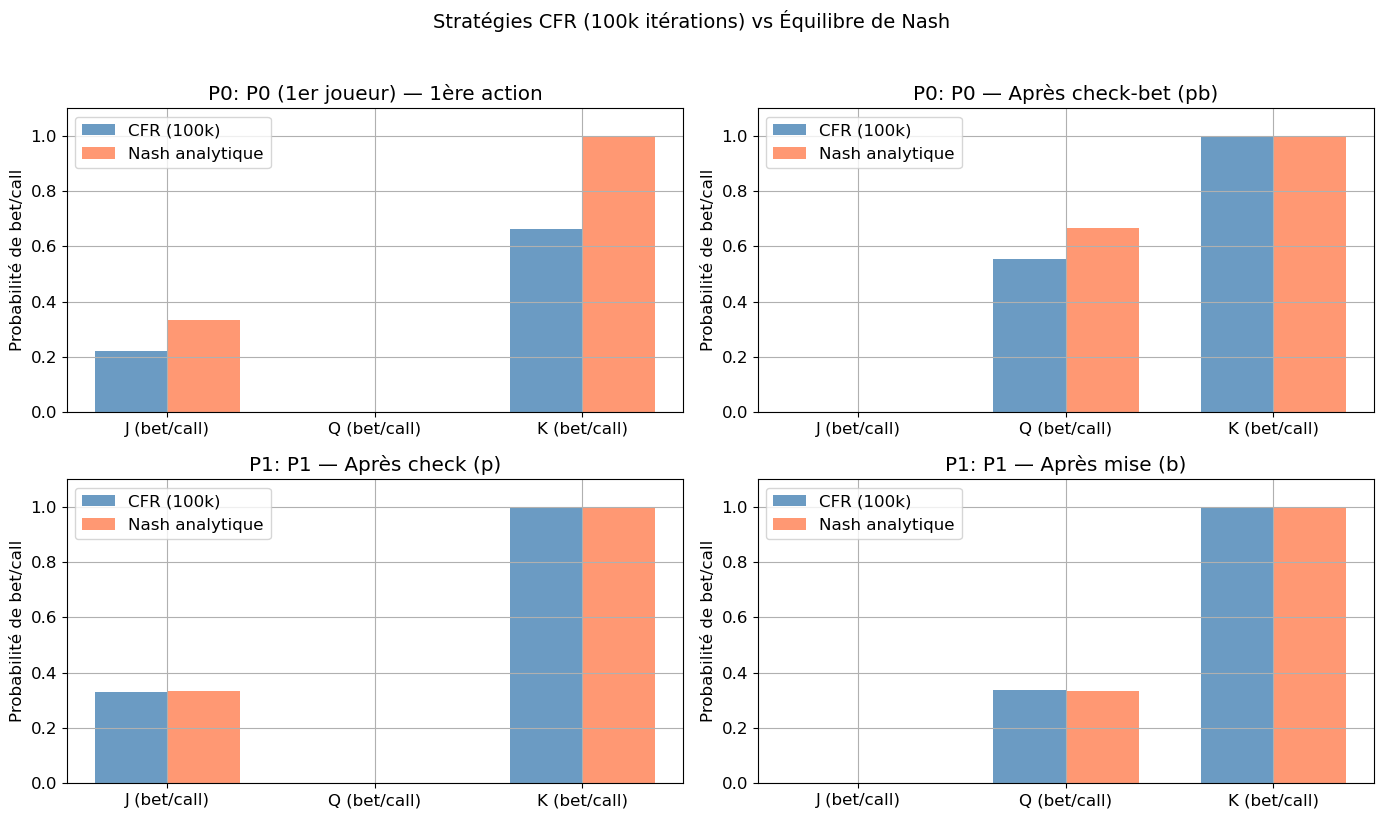

In [11]:
# Visualisation de la stratégie CFR vs Nash analytique
cfr_100k = CFR()
cfr_100k.train(100000)
profile_100k = cfr_100k.get_strategy_profile()

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

player_groups = [
    ('P0 (1er joueur) — 1ère action', ['J:', 'Q:', 'K:'], 0),
    ('P0 — Après check-bet (pb)', ['J:pb', 'Q:pb', 'K:pb'], 0),
    ('P1 — Après check (p)', ['J:p', 'Q:p', 'K:p'], 1),
    ('P1 — Après mise (b)', ['J:b', 'Q:b', 'K:b'], 1),
]

colors = ['steelblue', 'coral']

for ax, (title, keys, player) in zip(axes.flat, player_groups):
    x = np.arange(len(keys))
    width = 0.35
    
    cfr_bets = [profile_100k[k][1] for k in keys]
    nash_bets = [nash_reference[k][1] for k in keys]
    
    bars1 = ax.bar(x - width/2, cfr_bets, width, label='CFR (100k)', color='steelblue', alpha=0.8)
    bars2 = ax.bar(x + width/2, nash_bets, width, label='Nash analytique', color='coral', alpha=0.8)
    
    ax.set_xticks(x)
    ax.set_xticklabels([f'{k} (bet/call)' for k in ['J', 'Q', 'K']])
    ax.set_ylim(0, 1.1)
    ax.set_ylabel('Probabilité de bet/call')
    ax.set_title(f'P{player}: {title}')
    ax.legend()
    ax.axhline(0, color='k', linewidth=0.5)

plt.suptitle('Stratégies CFR (100k itérations) vs Équilibre de Nash', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('strategies_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.2 Analyse de la stratégie optimale

La stratégie Nash révèle plusieurs insights fondamentaux :

**Le bluff optimal** : J (la pire carte) doit bluffer exactement $1/3$ du temps.
- Trop de bluff → l'adversaire peut caller plus et profiter
- Trop peu → l'adversaire sait que bet = K, il peut fold à profit

**L'appel optimal** de Q face à une mise : appeler $1/3$ du temps.
- Cela rend le bluffeur avec J **indifférent** entre bluffer et ne pas bluffer

**La valeur négative** pour P0 ($-1/18$) : parler en premier est un désavantage car P0 révèle de l'information via ses actions, que P1 peut exploiter.

### 7.3 Récapitulatif numérique

In [12]:
# Tableau récapitulatif de performances
results_summary = []

for n_iter in [100, 500, 1000, 5000, 10000, 50000, 100000]:
    cfr_v = CFR()
    cfr_v.train(n_iter)
    expl_v = exploitability(cfr_v.get_strategy_profile())
    
    cfr_p = CFRPlus()
    cfr_p.train(n_iter)
    expl_p = exploitability(cfr_p.get_strategy_profile())
    
    results_summary.append((n_iter, expl_v, expl_p))

print(f"{'Iterations':>12s} {'CFR Vanilla':>14s} {'CFR+':>10s} {'Amélioration':>15s}")
print('-' * 55)
for n, ev, ep in results_summary:
    ratio = ev/ep if ep > 0 else float('inf')
    print(f"{n:>12,} {ev:>14.5f} {ep:>10.5f} {f'×{ratio:.2f}':>15s}")

  Iterations    CFR Vanilla       CFR+    Amélioration
-------------------------------------------------------
         100        0.04660    0.02973           ×1.57
         500        0.02442    0.01357           ×1.80
       1,000        0.01301    0.00972           ×1.34
       5,000        0.00466    0.00432           ×1.08
      10,000        0.00297    0.00305           ×0.97
      50,000        0.00202    0.00137           ×1.47
     100,000        0.00127    0.00097           ×1.31


---

## 8. Conclusion et Perspectives

### Résultats obtenus

1. **CFR vanilla** converge vers le Nash de Kuhn poker avec exploitabilité $\to 0$ en $O(1/\sqrt{T})$
2. **CFR+** converge légèrement plus vite (pondération linéaire, floor à 0)
3. **Oracle best-response** correctement implémenté pour les jeux à information imparfaite
4. **Scalabilité** : Leduc Hold'em est ~20× plus lent par itération, confirmant l'explosion combinatoire

### Connexion à l'IA Symbolique

CFR est un algorithme symbolique par nature :
- L'**arbre de jeu** est une structure formelle (graphe orienté, ensembles d'information)
- Les **stratégies** sont des fonctions de $\mathcal{I} \to \Delta(A)$ (distribs sur actions)
- La **convergence Nash** est garantie formellement (théorème de minimax de von Neumann)

### Breakthroughs historiques

| Système | Année | Variante | Technique clé |
|---------|-------|----------|---------------|
| Cepheus | 2015 | Limit HE 2p | CFR+ + card abstraction |
| Libratus | 2017 | No-Limit HE 2p | CFR + nested subgame solving |
| Pluribus | 2019 | No-Limit HE 6p | MCCFR + blueprint + real-time search |

### Perspectives

- **MCCFR (External Sampling)** : réduire le coût par itération de $O(|A|^d)$ à $O(|A|^{d/2})$
- **Deep CFR** (Brown 2019) : remplacer la table d'info sets par un réseau de neurones
- **Applications réelles** : enchères, négociations, sécurité (détection d'intrusions)

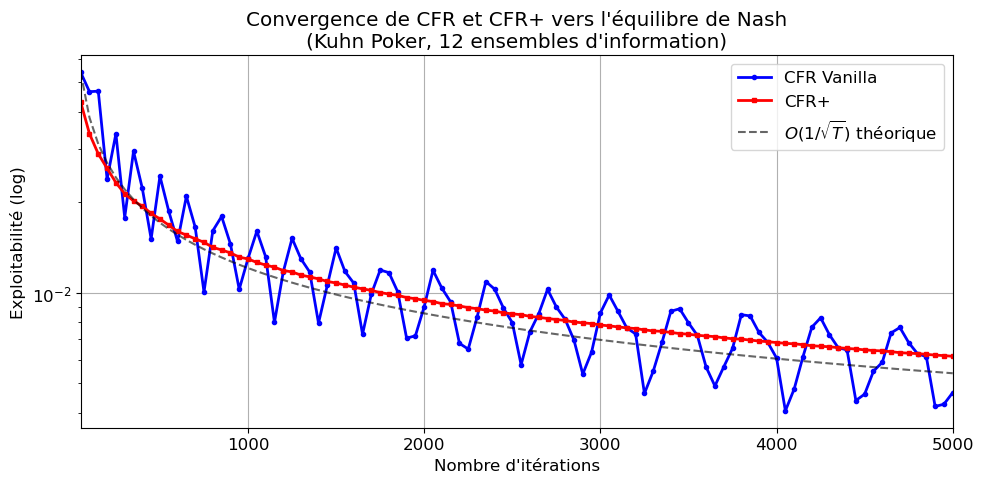


=== Résumé final ===
CFR  : exploitabilité après 5000 iter = 0.00466
CFR+ : exploitabilité après 5000 iter = 0.00616
Nash analytique : exploitabilité = 0.00000
Valeur du jeu Nash : -0.05556 (désavantage du 1er joueur)


In [13]:
# Visualisation finale : courbe convergence CFR vs CFR+
fig, ax = plt.subplots(figsize=(10, 5))

ax.semilogy(iters, expl_vanilla, 'b-o', markersize=3, label='CFR Vanilla', linewidth=2)
ax.semilogy(iters, expl_plus, 'r-s', markersize=3, label='CFR+', linewidth=2)

# Théorie : O(1/sqrt(T))
ref_t = np.array(iters)
ax.semilogy(ref_t, expl_vanilla[0] * np.sqrt(iters[0]/ref_t), 'k--', 
            alpha=0.6, label='$O(1/\\sqrt{T})$ théorique', linewidth=1.5)

ax.set_xlabel('Nombre d\'itérations')
ax.set_ylabel('Exploitabilité (log)')
ax.set_title('Convergence de CFR et CFR+ vers l\'équilibre de Nash\n(Kuhn Poker, 12 ensembles d\'information)')
ax.legend(fontsize=12)
ax.set_xlim(iters[0], iters[-1])

plt.tight_layout()
plt.savefig('convergence_final.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n=== Résumé final ===')
print(f'CFR  : exploitabilité après {N_ITER} iter = {expl_vanilla[-1]:.5f}')
print(f'CFR+ : exploitabilité après {N_ITER} iter = {expl_plus[-1]:.5f}')
print(f'Nash analytique : exploitabilité = 0.00000')
print(f'Valeur du jeu Nash : {-1/18:.5f} (désavantage du 1er joueur)')

---

## Références

1. **Zinkevich, M., Johanson, M., Bowling, M., & Piccione, C.** (2007). *Regret Minimization in Games with Incomplete Information*. NeurIPS 2007.

2. **Brown, N. & Sandholm, T.** (2019). *Superhuman AI for Multiplayer Poker*. Science, 365(6456), 885-890.

3. **Bowling, M., Burch, N., Johanson, M., & Tammelin, O.** (2015). *Heads-Up Limit Hold'em Poker Is Solved*. Science, 347(6218), 145-149.

4. **Burch, N., Moravcik, M., & Schmid, M.** (2018). *Revisiting CFR+ and alternating updates*. IJCAI 2019.

5. **Neller, T. & Lanctot, M.** (2013). *An Introduction to Counterfactual Regret Minimization*. AAAI Tutorial.

6. **Kuhn, H.W.** (1950). *Simplified two-person poker*. Contributions to the Theory of Games, 1, 97-103.